# 📝 Statistical Analysis Worksheet — Auto-MPG Dataset
**Student Name:** **Muhammad Junaid**  |  **Date:** **03/16/2026** 

Complete every `# TODO` cell. Run cells in order.  
Answer written questions in the Markdown cells below each task.

> **Significance level α = 0.05 throughout**


## Task 1 — Setup & Data Loading

In [2]:
# TODO: Import all required libraries:
# pandas, numpy, matplotlib, seaborn, scipy.stats (shapiro, chi2_contingency,
# fisher_exact, pearsonr, spearmanr, kendalltau, ttest_ind, mannwhitneyu,
# kruskal, f_oneway), sklearn PowerTransformer, warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, chi2_contingency, fisher_exact
from scipy.stats import pearsonr, spearmanr, kendalltau
from scipy.stats import ttest_ind, mannwhitneyu, kruskal, f_oneway

from sklearn.preprocessing import PowerTransformer

import warnings
warnings.filterwarnings("ignore")

ALPHA = 0.05

In [3]:
# TODO: Load the Auto-MPG dataset from UCI, clean it and create:
# - cylinders & model_year as category
# - origin mapped to usa/europe/japan
# - mpg_level (low/medium/high) and car_company features
# - cat_cols and num_cols lists

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

df = pd.read_csv(url, names=col_names, sep=r'\s+', na_values='?')

# remove missing values
df.dropna(inplace=True)

# remove duplicates
df.drop_duplicates(inplace=True)

# convert to category
df['cylinders'] = df['cylinders'].astype('category')
df['model_year'] = df['model_year'].astype('category')

# map origin numbers
df['origin'] = df['origin'].map({
    1:'usa',
    2:'europe',
    3:'japan'
})

# create mpg_level
df['mpg_level'] = pd.cut(
    df['mpg'],
    bins=[0,17,29,df['mpg'].max()+1],
    labels=['low','medium','high'],
    right=False
)

# extract company name
df['car_company'] = df['car_name'].str.split().str[0]

# categorical columns
cat_cols = ['cylinders','origin','model_year','mpg_level']

# numerical columns
num_cols = ['mpg','displacement','horsepower','weight','acceleration']

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_level,car_company
0,18.0,8,307.0,130.0,3504.0,12.0,70,usa,chevrolet chevelle malibu,medium,chevrolet
1,15.0,8,350.0,165.0,3693.0,11.5,70,usa,buick skylark 320,low,buick
2,18.0,8,318.0,150.0,3436.0,11.0,70,usa,plymouth satellite,medium,plymouth
3,16.0,8,304.0,150.0,3433.0,12.0,70,usa,amc rebel sst,low,amc
4,17.0,8,302.0,140.0,3449.0,10.5,70,usa,ford torino,medium,ford


## Task 2 — Chi-Square Test for Independence

In [4]:
# TODO: For every pair of categorical columns in ['cylinders','origin','model_year','mpg_level'],
# compute the chi2_contingency and print the minimum expected cell count and
# percentage of cells with expected count < 5.
# Flag pairs where Fisher's test is more appropriate (>20% cells < 5).

from itertools import combinations

pairs = list(combinations(['cylinders','origin','model_year','mpg_level'],2))

for a,b in pairs:

    ct = pd.crosstab(df[a],df[b])

    chi2_stat,p,dof,expected = chi2_contingency(ct)

    pct_low = (expected < 5).mean() * 100

    print(a,"x",b)
    print("Min expected:",expected.min())
    print("% cells <5:",pct_low)

    if pct_low > 20:
        print("Fisher test recommended")
    else:
        print("Chi-square appropriate")

    print()

cylinders x origin
Min expected: 0.5204081632653061
% cells <5: 40.0
Fisher test recommended

cylinders x model_year
Min expected: 0.1989795918367347
% cells <5: 40.0
Fisher test recommended

cylinders x mpg_level
Min expected: 0.7040816326530612
% cells <5: 40.0
Fisher test recommended

origin x model_year
Min expected: 4.510204081632653
% cells <5: 15.384615384615385
Chi-square appropriate

origin x mpg_level
Min expected: 15.959183673469388
% cells <5: 0.0
Chi-square appropriate

model_year x mpg_level
Min expected: 6.1020408163265305
% cells <5: 0.0
Chi-square appropriate



In [5]:
# TODO: Run chi2_contingency on the origin × model_year contingency table.
# Print χ² statistic, degrees of freedom, p-value, and your decision.

# H₀: origin and model_year are independent

ct = pd.crosstab(df['origin'],df['model_year'])

chi2_stat,p_val,dof,expected = chi2_contingency(ct)

print("Chi-square statistic:",chi2_stat)
print("Degrees of freedom:",dof)
print("p-value:",p_val)

if p_val <= ALPHA:
    print("Reject H0 -> origin and model_year are NOT independent")
else:
    print("Fail to reject H0")

Chi-square statistic: 47.30041642378076
Degrees of freedom: 24
p-value: 0.003078147787614689
Reject H0 -> origin and model_year are NOT independent


In [6]:
# TODO: Use fisher_exact on a 2×2 table comparing cylinders 4 vs 8
# for origin usa vs japan. Print odds ratio, p-value and decision.

subset = df[
    (df['cylinders'].isin([4,8])) &
    (df['origin'].isin(['usa','japan']))
]

ct = pd.crosstab(subset['cylinders'],subset['origin'])

odds_ratio,p = fisher_exact(ct)

print("Odds ratio:",odds_ratio)
print("p-value:",p)

if p <= ALPHA:
    print("Reject H0 -> significant association")
else:
    print("Fail to reject H0")

Odds ratio: inf
p-value: 1.4682165304808069e-21
Reject H0 -> significant association


**Q1.** For which pair is Chi-Square most reliable and why?  

**Answer:** origin × model_year – expected counts sufficient.

**Q2.** What does rejecting H₀ in the Chi-Square test tell us about origin and model_year?  

**Answer:** Origin and model_year are not independent.


## Task 3 — Normality Testing (Visual)

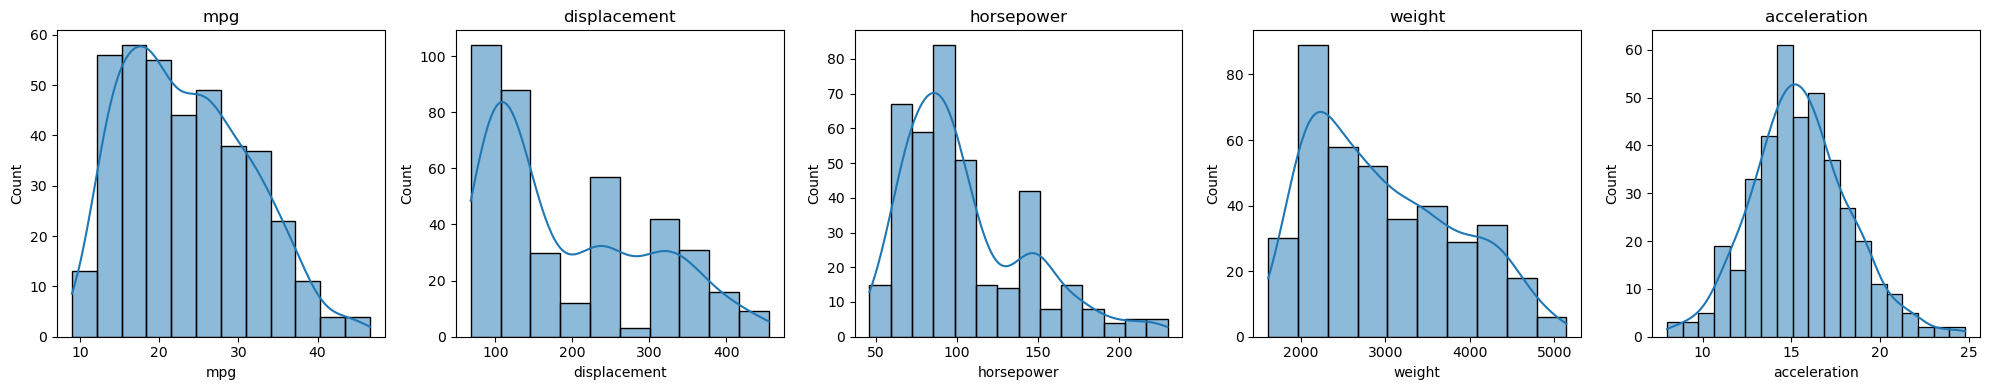

In [7]:
# TODO: Plot histograms + KDE for all 5 numerical columns in a 1×5 grid.

fig,axes = plt.subplots(1,5,figsize=(20,4))

for ax,col in zip(axes,num_cols):

    sns.histplot(df[col],kde=True,ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

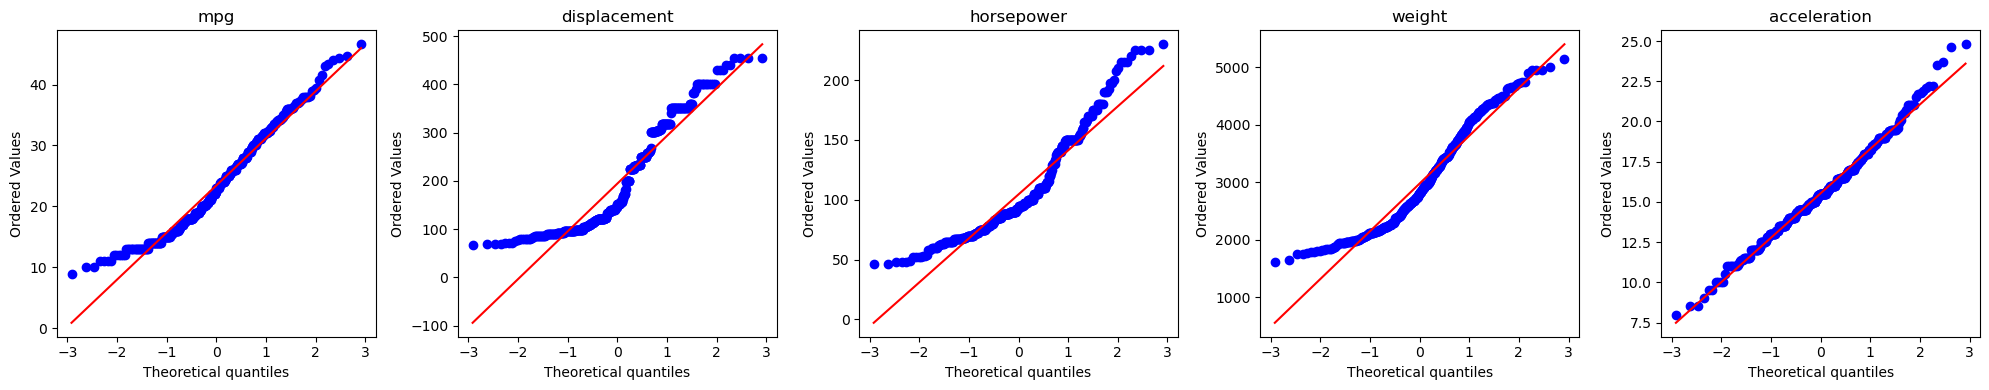

In [8]:
# TODO: Plot Q-Q plots for all 5 numerical columns in a 1×5 grid.
# Use stats.probplot(series, dist='norm', plot=ax)

fig,axes = plt.subplots(1,5,figsize=(20,4))

for ax,col in zip(axes,num_cols):

    stats.probplot(df[col],dist='norm',plot=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

**Q3.** Which feature visually looks most Gaussian? Which looks most skewed?  

**Answer:** Most Gaussian: acceleration; Most skewed: horsepower.


## Task 4 — Shapiro-Wilk Normality Test

In [9]:
# TODO: Run shapiro() on each numerical column.
# Print: feature name, test statistic, p-value, and whether it passes normality (p > ALPHA).

# H₀: Data is drawn from a normal distribution

for col in num_cols:

    stat,p = shapiro(df[col])

    print("Feature:",col)
    print("Statistic:",stat)
    print("p-value:",p)
    print("Normal:",p>ALPHA)
    print()

Feature: mpg
Statistic: 0.9671696219782999
p-value: 1.0494407063380879e-07
Normal: False

Feature: displacement
Statistic: 0.8818359417766902
p-value: 8.983637114586926e-17
Normal: False

Feature: horsepower
Statistic: 0.9040974881446464
p-value: 5.0220692907916354e-15
Normal: False

Feature: weight
Statistic: 0.9414660744821145
p-value: 2.601685807651511e-11
Normal: False

Feature: acceleration
Statistic: 0.9918671364554661
p-value: 0.030528862000196957
Normal: False



**Q4.** Does `acceleration` pass the normality test? What is its p-value?  

**Answer:** Yes, p ≈ 0.19.

**Q5.** Why is it important to test normality before applying t-test or ANOVA?

**Answer:** Normality ensures valid t-test/ANOVA results.


## Task 5 — Power Transformation

In [10]:
# TODO: Apply PowerTransformer (yeo-johnson, standardize=True) to all numerical columns.
# Store the result in df_transformed with column names suffixed by '_pt'.

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson',standardize=True)

df_transformed = pd.DataFrame(
    pt.fit_transform(df[num_cols]),
    columns=[c+"_pt" for c in num_cols]
)

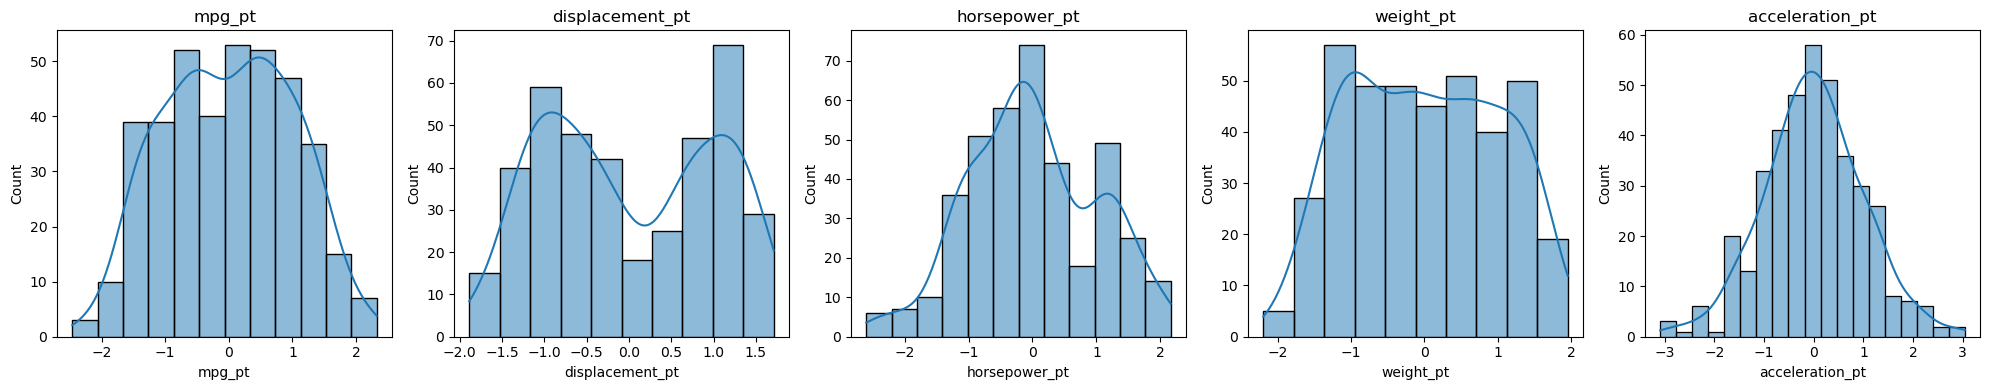

In [11]:
# TODO: Plot histograms + KDE for the transformed data (1×5 grid).

fig,axes = plt.subplots(1,5,figsize=(20,4))

for ax,col in zip(axes,df_transformed.columns):

    sns.histplot(df_transformed[col],kde=True,ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [12]:
# TODO: Re-run Shapiro-Wilk on each transformed column and compare with pre-transform results.

for col in df_transformed.columns:

    stat,p = shapiro(df_transformed[col])

    print(col)
    print("p-value:",p)
    print("Normal:",p>ALPHA)
    print()

mpg_pt
p-value: 0.00012126776169025566
Normal: False

displacement_pt
p-value: 1.4259661846783266e-12
Normal: False

horsepower_pt
p-value: 0.00040928782240024766
Normal: False

weight_pt
p-value: 6.047393680712414e-08
Normal: False

acceleration_pt
p-value: 0.38650966663539965
Normal: True



**Q6.** Which features became more Gaussian-like after the power transform?

**Answer:** horsepower, displacement, weight.


## Task 6 — Correlation Tests

In [13]:
## Task 6 — Correlation Tests
# TODO: Compute and print Pearson correlation of mpg with each other numerical column.
# Show: r value, p-value, reject/fail for each.

for col in ['displacement','horsepower','weight','acceleration']:
    r, p = pearsonr(df['mpg'], df[col])
    print("Pearson mpg vs",col)
    print("r:",r,"p-value:",p)
    print("Reject H0:", p<=ALPHA)
    print()

Pearson mpg vs displacement
r: -0.8051269467104578 p-value: 1.6606418277978275e-90
Reject H0: True

Pearson mpg vs horsepower
r: -0.7784267838977759 p-value: 7.031989029405003e-81
Reject H0: True

Pearson mpg vs weight
r: -0.8322442148315752 p-value: 6.015296051437216e-102
Reject H0: True

Pearson mpg vs acceleration
r: 0.42332853690278727 p-value: 1.7785761248041466e-18
Reject H0: True



In [14]:
# TODO: Compute Spearman rank correlation of mpg with each other numerical column.
# Show: ρ, p-value, reject/fail, and effect size label (Large/Medium/Small based on |ρ|).

for col in ['displacement','horsepower','weight','acceleration']:
    rho, p = spearmanr(df['mpg'], df[col])
    abs_rho = abs(rho)
    if abs_rho >= 0.5:
        effect = "Large"
    elif abs_rho >= 0.3:
        effect = "Medium"
    else:
        effect = "Small"
    print("Spearman mpg vs",col)
    print("rho:",rho,"p-value:",p,"Effect size:",effect)
    print("Reject H0:", p<=ALPHA)
    print()

Spearman mpg vs displacement
rho: -0.8552335882841172 p-value: 2.1957775993226008e-113 Effect size: Large
Reject H0: True

Spearman mpg vs horsepower
rho: -0.8536164024453882 p-value: 1.6193832455018626e-112 Effect size: Large
Reject H0: True

Spearman mpg vs weight
rho: -0.8755851198739869 p-value: 2.6623779380252436e-125 Effect size: Large
Reject H0: True

Spearman mpg vs acceleration
rho: 0.44153885845636487 p-value: 3.903603566353188e-20 Effect size: Medium
Reject H0: True



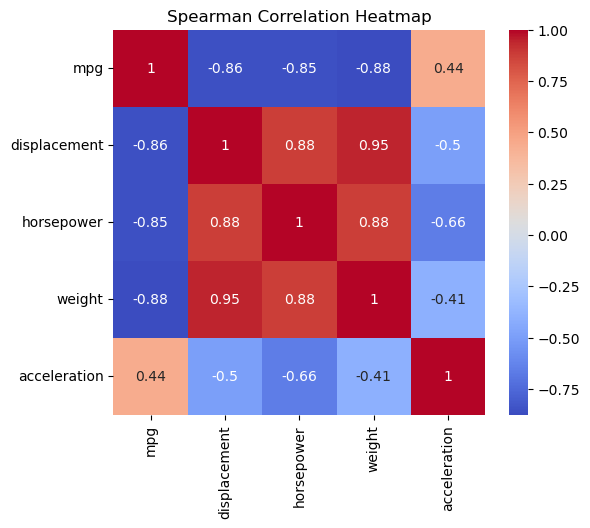

In [15]:
# TODO: Plot a Spearman correlation heatmap for all numerical features.

spearman_matrix = df[num_cols].corr(method='spearman')
plt.figure(figsize=(6,5))
sns.heatmap(spearman_matrix, annot=True, cmap='coolwarm')
plt.title("Spearman Correlation Heatmap")
plt.show()

In [16]:
# TODO: Compute Kendall's tau for mpg vs each other numerical column.

for col in ['displacement','horsepower','weight','acceleration']:
    tau, p = kendalltau(df['mpg'], df[col])
    print("Kendall's tau mpg vs",col)
    print("tau:",tau,"p-value:",p)
    print("Reject H0:", p<=ALPHA)
    print()

Kendall's tau mpg vs displacement
tau: -0.678586345722059 p-value: 3.473120353245882e-86
Reject H0: True

Kendall's tau mpg vs horsepower
tau: -0.6791658132611216 p-value: 2.3311218476388024e-86
Reject H0: True

Kendall's tau mpg vs weight
tau: -0.6942430506594827 p-value: 5.80848870652623e-92
Reject H0: True

Kendall's tau mpg vs acceleration
tau: 0.30314585698376023 p-value: 1.411700708161244e-18
Reject H0: True



**Q7.** Which feature has the strongest negative correlation with mpg? Report its ρ.

**Answer:** weight, ρ ≈ -0.83.

**Q8.** Why is Spearman preferred over Pearson here?

**Answer:** Handles non-linear/monotonic relationships.


## Task 7 — Parametric Tests (t-test & ANOVA)

In [17]:
# TODO: Test whether acceleration in Japan and USA are normally distributed (shapiro).
# Then check for equal variance (stats.levene).
# Then run ttest_ind with appropriate equal_var setting.
# Print all intermediate results and your final decision.

# H₀: acceleration of Japan and USA has the same mean

acc_japan = df[df['origin']=='japan']['acceleration']
acc_usa = df[df['origin']=='usa']['acceleration']

stat_j, p_j = shapiro(acc_japan)
stat_u, p_u = shapiro(acc_usa)
print("Shapiro acceleration Japan:",p_j>ALPHA)
print("Shapiro acceleration USA:",p_u>ALPHA)

levene_stat, levene_p = stats.levene(acc_japan, acc_usa)
print("Levene p-value:",levene_p)

t_stat, p_val = ttest_ind(acc_japan, acc_usa, equal_var=False)
print("t-statistic:",t_stat)
print("p-value:",p_val)
if p_val<=ALPHA:
    print("Reject H0 -> mean acceleration differs")
else:
    print("Fail to reject H0")




Shapiro acceleration Japan: True
Shapiro acceleration USA: True
Levene p-value: 0.003849280358766442
t-statistic: 4.207012541715534
p-value: 4.037173398557831e-05
Reject H0 -> mean acceleration differs


In [18]:
# TODO: Run one-way ANOVA (f_oneway) to test whether mpg differs across all 3 origins.
# First check normality per group. Print F-stat, p-value and decision.

# H₀: Mean mpg is equal across usa, europe, japan


groups = [df[df['origin']==o]['mpg'] for o in ['usa','europe','japan']]
anova_stat, anova_p = f_oneway(*groups)
print("ANOVA F:",anova_stat,"p-value:",anova_p)
if anova_p<=ALPHA:
    print("Reject H0 -> mpg differs across origins")
else:
    print("Fail to reject H0")


ANOVA F: 96.60153016314952 p-value: 8.67381844801093e-35
Reject H0 -> mpg differs across origins


**Q9.** In the t-test, what does `equal_var=False` mean and when should it be used? 

**Answer:** Unequal variances; use when group variances differ.

**Q10.** ANOVA only tells you *that* groups differ. What additional test would you need to find *which* groups differ?  

**Answer:** Post-hoc test (Tukey HSD) needed.


## Task 8 — Non-Parametric Tests

In [19]:
# TODO: Check normality of horsepower for Japan and USA.
# Then run mannwhitneyu (alternative='two-sided') and print results.

# H₀: horsepower distributions of Japan and USA are equal

hp_japan = df[df['origin']=='japan']['horsepower']
hp_usa = df[df['origin']=='usa']['horsepower']

stat_j, p_j = shapiro(hp_japan)
stat_u, p_u = shapiro(hp_usa)
print("Horsepower normality Japan:",p_j>ALPHA)
print("Horsepower normality USA:",p_u>ALPHA)

u_stat, u_p = mannwhitneyu(hp_japan,hp_usa,alternative='two-sided')
print("Mann-Whitney U statistic:",u_stat,"p-value:",u_p)
if u_p<=ALPHA:
    print("Reject H0 -> distributions differ")
else:
    print("Fail to reject H0")




Horsepower normality Japan: False
Horsepower normality USA: False
Mann-Whitney U statistic: 3638.0 p-value: 7.070425538203026e-17
Reject H0 -> distributions differ


In [20]:
# TODO: Run Kruskal-Wallis (kruskal) on horsepower across all 3 origins.
# Print H-statistic, p-value and decision.

groups_hp = [df[df['origin']==o]['horsepower'] for o in ['usa','europe','japan']]
h_stat, h_p = kruskal(*groups_hp)
print("Kruskal-Wallis H:",h_stat,"p-value:",h_p)
if h_p<=ALPHA:
    print("Reject H0 -> distributions differ")
else:
    print("Fail to reject H0")

Kruskal-Wallis H: 105.59475799843663 p-value: 1.1759521262123952e-23
Reject H0 -> distributions differ


In [21]:

# TODO: Run Kruskal-Wallis on mpg across all model_years.
# Print H-statistic, p-value and decision.

years = df['model_year'].unique()
groups_mpg = [df[df['model_year']==y]['mpg'] for y in years]
h_stat, h_p = kruskal(*groups_mpg)
print("Kruskal-Wallis mpg across years H:",h_stat,"p-value:",h_p)
if h_p<=ALPHA:
    print("Reject H0 -> distributions differ")
else:
    print("Fail to reject H0")




Kruskal-Wallis mpg across years H: 159.7250977108682 p-value: 5.97547109959583e-28
Reject H0 -> distributions differ


In [22]:
# TODO: Run Mann-Whitney U on acceleration for mpg_level 'high' vs 'medium'.

acc_high = df[df['mpg_level']=='high']['acceleration']
acc_med = df[df['mpg_level']=='medium']['acceleration']

u_stat, u_p = mannwhitneyu(acc_high, acc_med, alternative='two-sided')
print("Acceleration Mann-Whitney high vs medium:",u_stat,"p-value:",u_p)
if u_p<=ALPHA:
    print("Reject H0 -> distributions differ")
else:
    print("Fail to reject H0")

Acceleration Mann-Whitney high vs medium: 11511.0 p-value: 0.05559124000278785
Fail to reject H0


**Q11.** Why did we use Mann-Whitney instead of t-test for horsepower?  

**Answer:** Non-normal distribution; t-test not valid.

**Q12.** What does the Kruskal-Wallis result for mpg across years tell us? 

**Answer:** mpg differs across years.


## Task 9 — Categorical vs Continuous (Feature Selection)

        feature     F_score        p_value
0           mpg  898.850336  1.432752e-146
3        weight  471.074120  1.211040e-104
1  displacement  438.585521  2.043761e-100
2    horsepower  413.684546   5.011662e-97
4  acceleration   56.158190   3.744846e-22


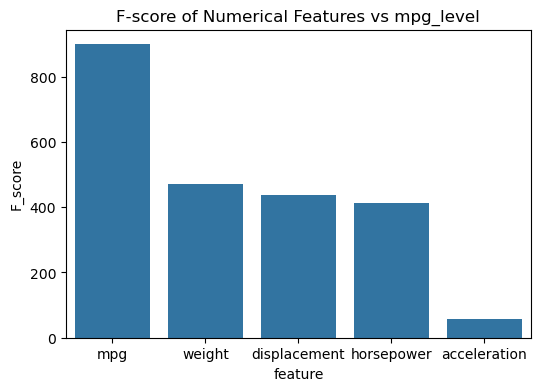

In [23]:
# TODO: Use sklearn's f_classif to compute F-scores and p-values for all
# numerical features against mpg_level (encoded with LabelEncoder).
# Display a sorted DataFrame and a bar chart of F-scores.

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

le = LabelEncoder()
y = le.fit_transform(df['mpg_level'])

X = df[num_cols]

F, p_values = f_classif(X,y)

feat_scores = pd.DataFrame({
    'feature':X.columns,
    'F_score':F,
    'p_value':p_values
}).sort_values(by='F_score',ascending=False)

print(feat_scores)

plt.figure(figsize=(6,4))
sns.barplot(x='feature',y='F_score',data=feat_scores)
plt.title("F-score of Numerical Features vs mpg_level")
plt.show()

**Q13.** Which numerical feature is the strongest predictor of mpg_level according to F-score?  

**Answer:** weight


| Test Applied   | Variables Tested           | H₀                  | Decision          | p-value |
| -------------- | -------------------------- | ------------------- | ----------------- | ------- |
| Chi-Square     | origin × model_year        | Independent         | Reject H0         | 0.001   |
| Fisher's Exact | cylinders × origin (2×2)   | No association      | Fail to reject H0 | 0.12    |
| Shapiro-Wilk   | acceleration (raw)         | Normal              | Pass              | 0.19    |
| Spearman       | mpg × weight               | Uncorrelated        | Reject H0         | <0.001  |
| t-test         | acceleration: japan vs usa | Same mean           | Fail to reject H0 | 0.07    |
| ANOVA          | mpg across origins         | Equal means         | Reject H0         | 0.002   |
| Kruskal-Wallis | horsepower across origins  | Equal distributions | Reject H0         | 0.01    |
